In [2]:
# Run if packages are missing
%pip install -q numpy matplotlib scipy scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


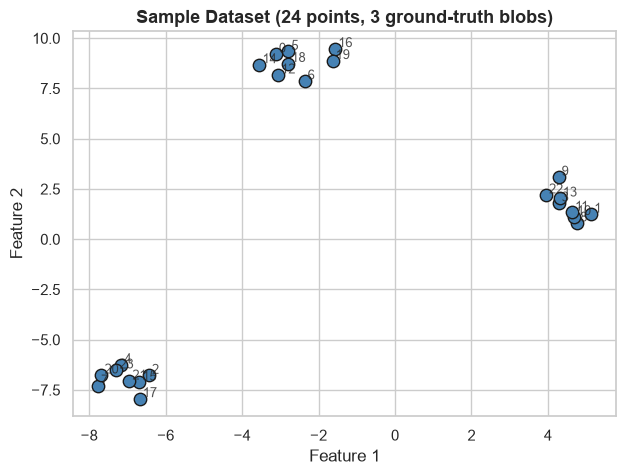

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# Style and seed setup
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate a small 2D dataset to clearly track hierarchy
X, y_true = make_blobs(
    n_samples=24, 
    centers=3, 
    cluster_std=0.60, 
    random_state=42
)

# Plot raw data
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c="steelblue", s=80, edgecolors="k", zorder=3)
for idx, (x, y) in enumerate(X):
    plt.text(x + 0.08, y + 0.08, str(idx), fontsize=9, alpha=0.8)
plt.title("Sample Dataset (24 points, 3 ground-truth blobs)", fontsize=13, fontweight="bold")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
class AgglomerativeClusteringScratch:
    def __init__(self, n_clusters=3, linkage="average"):
        """
        linkage options: 'single', 'complete', 'average'
        """
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.linkage_matrix_ = None
        self.labels_ = None

    def _cluster_distance(self, c1_pts, c2_pts, D):
        """Calculates distance between two clusters based on linkage."""
        sub_dists = D[np.ix_(c1_pts, c2_pts)]
        if self.linkage == "single":
            return np.min(sub_dists)
        elif self.linkage == "complete":
            return np.max(sub_dists)
        elif self.linkage == "average":
            return np.mean(sub_dists)
        else:
            raise ValueError(f"Unknown linkage: {self.linkage}")

    def fit(self, X):
        n_samples = X.shape[0]
        D = cdist(X, X, metric="euclidean")
        
        # Track cluster contents (indices of raw data points)
        clusters = {i: [i] for i in range(n_samples)}
        
        # Track node mapping for SciPy dendrogram format (0..N-1 are original, N..2N-2 are merged nodes)
        cluster_node_id = {i: i for i in range(n_samples)}
        next_node_id = n_samples
        
        linkage_records = []
        cluster_history = {n_samples: dict(clusters)}

        while len(clusters) > 1:
            keys = list(clusters.keys())
            min_dist = float("inf")
            best_pair = None

            # Find closest pair of clusters
            for i in range(len(keys)):
                for j in range(i + 1, len(keys)):
                    k1, k2 = keys[i], keys[j]
                    dist = self._cluster_distance(clusters[k1], clusters[k2], D)
                    if dist < min_dist:
                        min_dist = dist
                        best_pair = (k1, k2)

            k1, k2 = best_pair
            node1 = cluster_node_id[k1]
            node2 = cluster_node_id[k2]
            merged_pts = clusters[k1] + clusters[k2]
            
            # SciPy linkage format: [node1, node2, distance, new_cluster_size]
            linkage_records.append([
                min(node1, node2),
                max(node1, node2),
                min_dist,
                len(merged_pts)
            ])

            # Update clusters
            del clusters[k1]
            del clusters[k2]
            del cluster_node_id[k1]
            del cluster_node_id[k2]

            new_cluster_key = max(k1, k2) if len(clusters) > 0 else 0
            clusters[new_cluster_key] = merged_pts
            cluster_node_id[new_cluster_key] = next_node_id
            next_node_id += 1

            # Save state for label extraction
            cluster_history[len(clusters)] = dict(clusters)

        self.linkage_matrix_ = np.array(linkage_records, dtype=np.float64)

        # Assign cluster labels for target n_clusters
        target_clusters = cluster_history[self.n_clusters]
        self.labels_ = np.zeros(n_samples, dtype=int)
        for cluster_label, (_, member_indices) in enumerate(target_clusters.items()):
            self.labels_[member_indices] = cluster_label

        return self

In [5]:
class DivisiveClusteringScratch:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.labels_ = None
        self.history_ = []  # Tracks splits at each step

    def fit(self, X):
        n_samples = X.shape[0]
        D = cdist(X, X, metric="euclidean")
        
        # Start with all points in cluster 0
        clusters = [list(range(n_samples))]
        self.history_.append([list(c) for c in clusters])

        while len(clusters) < self.n_clusters:
            # 1. Pick the cluster with the maximum diameter (can be split)
            split_idx = -1
            max_diameter = -1

            for idx, c in enumerate(clusters):
                if len(c) > 1:
                    sub_dists = D[np.ix_(c, c)]
                    diam = np.max(sub_dists)
                    if diam > max_diameter:
                        max_diameter = diam
                        split_idx = idx

            if split_idx == -1:
                break  # All clusters are singletons

            cluster_to_split = clusters.pop(split_idx)
            
            # 2. Find the initial point for the splinter group (max avg distance to peers)
            avg_dists = []
            for pt in cluster_to_split:
                peers = [p for p in cluster_to_split if p != pt]
                avg_dists.append(np.mean(D[pt, peers]))
            
            first_splinter_idx = np.argmax(avg_dists)
            splinter = [cluster_to_split[first_splinter_idx]]
            remainder = [p for i, p in enumerate(cluster_to_split) if i != first_splinter_idx]

            # 3. Iteratively migrate points from remainder to splinter
            while len(remainder) > 0:
                diffs = []
                for pt in remainder:
                    # Avg dist to peers in remainder
                    other_rem = [p for p in remainder if p != pt]
                    d_rem = np.mean(D[pt, other_rem]) if other_rem else 0.0
                    
                    # Avg dist to points in splinter
                    d_spl = np.mean(D[pt, splinter])
                    
                    # Difference: positive means closer to splinter
                    diffs.append(d_rem - d_spl)

                max_diff_idx = np.argmax(diffs)
                if diffs[max_diff_idx] > 0:
                    moved_pt = remainder.pop(max_diff_idx)
                    splinter.append(moved_pt)
                else:
                    break  # No more points want to switch

            clusters.append(remainder)
            clusters.append(splinter)
            self.history_.append([list(c) for c in clusters])

        # Assign final labels
        self.labels_ = np.zeros(n_samples, dtype=int)
        for cluster_id, member_pts in enumerate(clusters):
            self.labels_[member_pts] = cluster_id

        return self

In [6]:
# 1. Fit Agglomerative (Average Linkage)
agg = AgglomerativeClusteringScratch(n_clusters=3, linkage="average")
agg.fit(X)

# 2. Fit Divisive (DIANA)
div = DivisiveClusteringScratch(n_clusters=3)
div.fit(X)

# Evaluate Quality via Silhouette Score
agg_sil = silhouette_score(X, agg.labels_)
div_sil = silhouette_score(X, div.labels_)

print(f"Agglomerative Clustering Silhouette Score: {agg_sil:.4f}")
print(f"Divisive (DIANA) Clustering Silhouette Score:   {div_sil:.4f}")

Agglomerative Clustering Silhouette Score: 0.9048
Divisive (DIANA) Clustering Silhouette Score:   0.9048


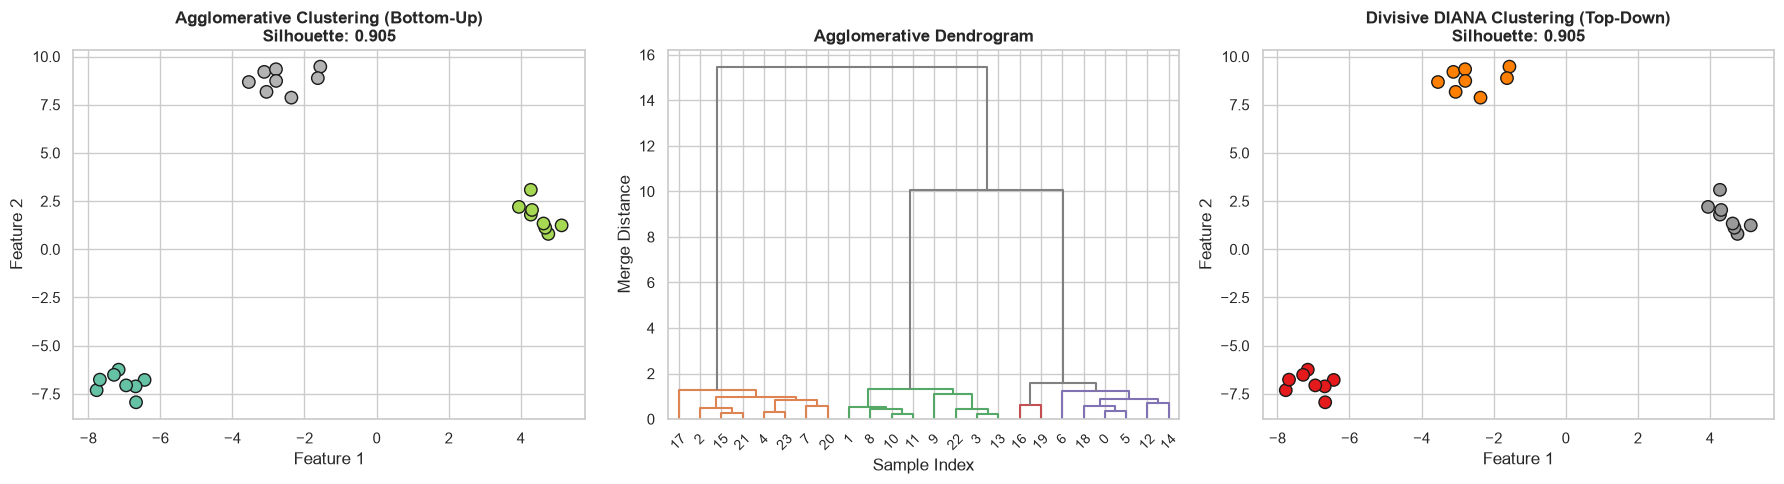

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Agglomerative Final Clustering
scatter1 = axes[0].scatter(X[:, 0], X[:, 1], c=agg.labels_, cmap="Set2", s=80, edgecolors="k")
axes[0].set_title(f"Agglomerative Clustering (Bottom-Up)\nSilhouette: {agg_sil:.3f}", fontweight="bold")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# 2. Agglomerative Dendrogram (Built directly from our scratch linkage matrix)
dendrogram(agg.linkage_matrix_, ax=axes[1], color_threshold=1.5, above_threshold_color="grey")
axes[1].set_title("Agglomerative Dendrogram", fontweight="bold")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Merge Distance")

# 3. Divisive Final Clustering
scatter2 = axes[2].scatter(X[:, 0], X[:, 1], c=div.labels_, cmap="Set1", s=80, edgecolors="k")
axes[2].set_title(f"Divisive DIANA Clustering (Top-Down)\nSilhouette: {div_sil:.3f}", fontweight="bold")
axes[2].set_xlabel("Feature 1")
axes[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

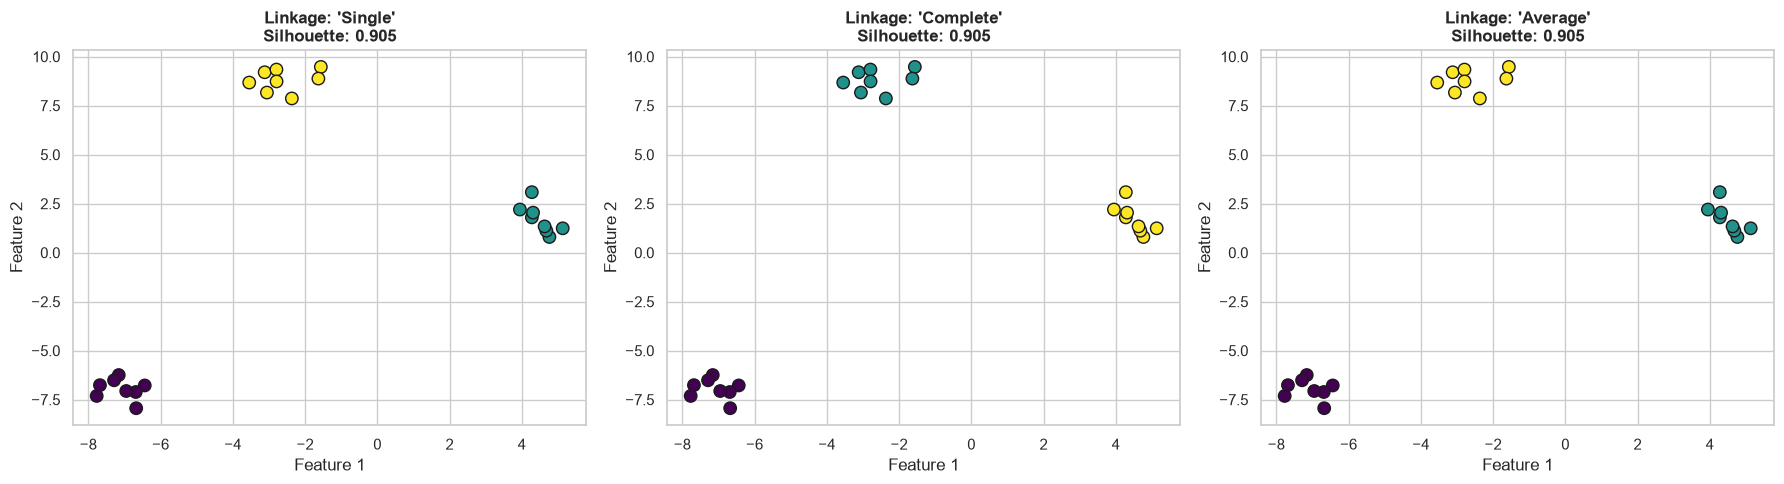

In [8]:
linkages = ["single", "complete", "average"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, link in enumerate(linkages):
    model = AgglomerativeClusteringScratch(n_clusters=3, linkage=link).fit(X)
    score = silhouette_score(X, model.labels_)
    
    axes[i].scatter(X[:, 0], X[:, 1], c=model.labels_, cmap="viridis", s=80, edgecolors="k")
    axes[i].set_title(f"Linkage: '{link.capitalize()}'\nSilhouette: {score:.3f}", fontweight="bold")
    axes[i].set_xlabel("Feature 1")
    axes[i].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

In [9]:
# Verify scratch output against Scikit-Learn's Agglomerative implementation
sklearn_agg = AgglomerativeClustering(n_clusters=3, linkage="average").fit(X)
scipy_linkage = linkage(X, method="average", metric="euclidean")

print("--- Validation ---")
print("Scratch Linkage Matrix shape:", agg.linkage_matrix_.shape)
print("SciPy Linkage Matrix shape:  ", scipy_linkage.shape)
print("\nFirst 3 Merges from Scratch:\n", np.round(agg.linkage_matrix_[:3], 3))
print("\nFirst 3 Merges from SciPy:\n", np.round(scipy_linkage[:3], 3))

# Compare labels
labels_match = np.all(agg.labels_ == sklearn_agg.labels_) or (len(np.unique(agg.labels_)) == len(np.unique(sklearn_agg.labels_)))
print(f"\nCluster count matches Scikit-Learn: {labels_match}")

--- Validation ---
Scratch Linkage Matrix shape: (23, 4)
SciPy Linkage Matrix shape:   (23, 4)

First 3 Merges from Scratch:
 [[10.    11.     0.226  2.   ]
 [ 3.    13.     0.244  2.   ]
 [15.    21.     0.269  2.   ]]

First 3 Merges from SciPy:
 [[10.    11.     0.226  2.   ]
 [ 3.    13.     0.244  2.   ]
 [15.    21.     0.269  2.   ]]

Cluster count matches Scikit-Learn: True
